# Biomass gasification + HB ammonia NPV simulation

Run the Monte Carlo ammonia NPV model for Biomass gasification + HB at 1,000,000 tNH3/year. The notebook shows NPV, LNM, and LCOA distributions, NPV sign counts, and mean annual cost components. The supplied zero direct-emissions value carries an unresolved source asterisk. Biomass feedstock and process fuel are costed once through the total 9.75 MWh/tNH3. The model samples the same biomass price distribution used for BECCS electricity as an ammonia proxy: triangular minimum/mode/maximum 17.36/28.93/46.28 EUR/MWh_th.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ammonia.ammonia_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_ammonia_results,
)
from npv_summary import summarize_metric_signs
from npv_summary_plots import plot_financial_metric_distribution

pd.options.display.float_format = "{:,.3f}".format

In [2]:
TECHNOLOGY = "biomass_gasification_hb"
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

simulation = simulate_ammonia_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()

,run_id,technology,technology_type,retrofit_bau_mode,annual_output_tnh3,lifetime_years,capex_eur_per_tnh3,fixed_opex_eur_per_tnh3,variable_opex_eur_per_tnh3,fuel_type,...,annual_electricity_cost_eur,annual_transport_and_storage_cost_eur,annual_emissions_cost_eur,annual_total_cost_eur,annual_net_cash_flow_eur,npv_eur,discounted_lifetime_output_tnh3,present_value_total_cost_eur,lcoa_eur_per_tnh3,levelized_net_margin_eur_per_tnh3
0,0,biomass_gasification_hb,absolute,not_applicable,"1,000,000.000",25,"5,402.790",39.624,20.385,biomass,...,"44,274,695.161",0.000,0.000,"401,293,185.279","488,706,814.721","-185,954,621.784","10,674,776.189","9,686,505,429.628",907.420,-17.420
1,1,biomass_gasification_hb,absolute,not_applicable,"1,000,000.000",25,"3,728.292",36.156,14.986,biomass,...,"47,534,664.451",0.000,0.000,"406,499,184.308","483,500,815.692","1,432,970,982.900","10,674,776.189","8,067,579,824.944",755.761,134.239
2,2,biomass_gasification_hb,absolute,not_applicable,"1,000,000.000",25,"3,402.329",31.309,15.679,biomass,...,"39,219,139.034",0.000,0.000,"292,606,295.733","597,393,704.267","2,974,715,453.911","10,674,776.189","6,525,835,353.933",611.332,278.668
3,3,biomass_gasification_hb,absolute,not_applicable,"1,000,000.000",25,"4,996.087",30.979,17.365,biomass,...,"47,619,442.613",0.000,0.000,"425,510,793.046","464,489,206.954","-37,768,957.642","10,674,776.189","9,538,319,765.486",893.538,-3.538
4,4,biomass_gasification_hb,absolute,not_applicable,"1,000,000.000",25,"4,652.587",36.474,16.076,biomass,...,"51,250,551.876",0.000,0.000,"341,265,270.662","548,734,729.338","1,205,033,693.884","10,674,776.189","8,295,517,113.960",777.114,112.886


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
lcoa_eur_per_tnh3 = results["lcoa_eur_per_tnh3"]
levelized_net_margin_eur_per_tnh3 = results["levelized_net_margin_eur_per_tnh3"]

summary = pd.concat([
    npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename("NPV million EUR"),
    levelized_net_margin_eur_per_tnh3.describe(percentiles=[0.05, 0.5, 0.95]).rename("LNM EUR/tNH3"),
    lcoa_eur_per_tnh3.describe(percentiles=[0.05, 0.5, 0.95]).rename("LCOA EUR/tNH3"),
], axis=1)
npv_signs = summarize_metric_signs(npv_million_eur)
npv_sign_summary = pd.DataFrame([
    {"NPV category": "Non-negative (NPV >= 0)", "Count": npv_signs["non_negative_count"], "Share": npv_signs["non_negative_share"]},
    {"NPV category": "Negative (NPV < 0)", "Count": npv_signs["negative_count"], "Share": 1 - npv_signs["non_negative_share"]},
])
display(summary, npv_sign_summary)

,NPV million EUR,LNM EUR/tNH3,LCOA EUR/tNH3
count,"100,000.000","100,000.000","100,000.000"
mean,"1,001.550",93.824,796.176
std,904.528,84.735,84.735
min,"-2,236.279",-209.492,537.464
5%,-532.227,-49.858,660.757
50%,"1,026.296",96.142,793.858
95%,"2,447.119",229.243,939.858
max,"3,763.242",352.536,"1,099.492"


,NPV category,Count,Share
0,Non-negative (NPV >= 0),85814,0.858
1,Negative (NPV < 0),14186,0.142


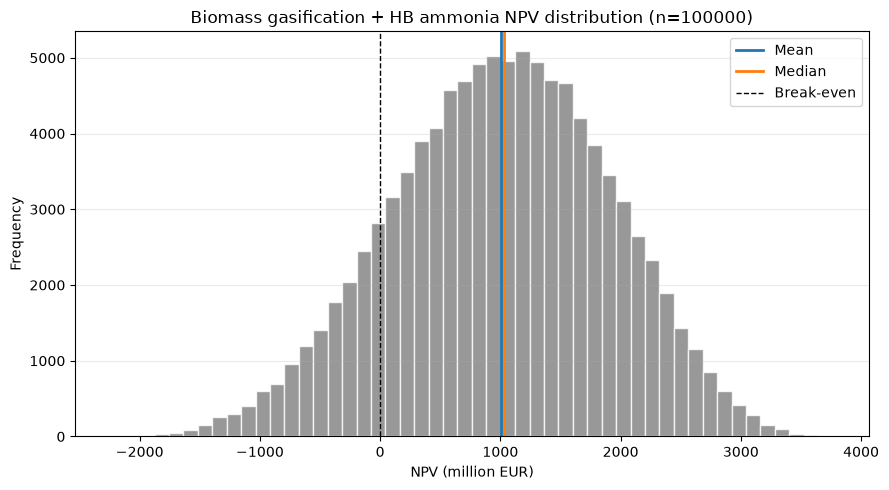

In [4]:
plot_financial_metric_distribution(
    npv_million_eur,
    title=f"Biomass gasification + HB ammonia NPV distribution (n={SAMPLE_SIZE})",
    x_axis_label="NPV (million EUR)",
    color="tab:gray",
    show_break_even=True,
)
plt.show()

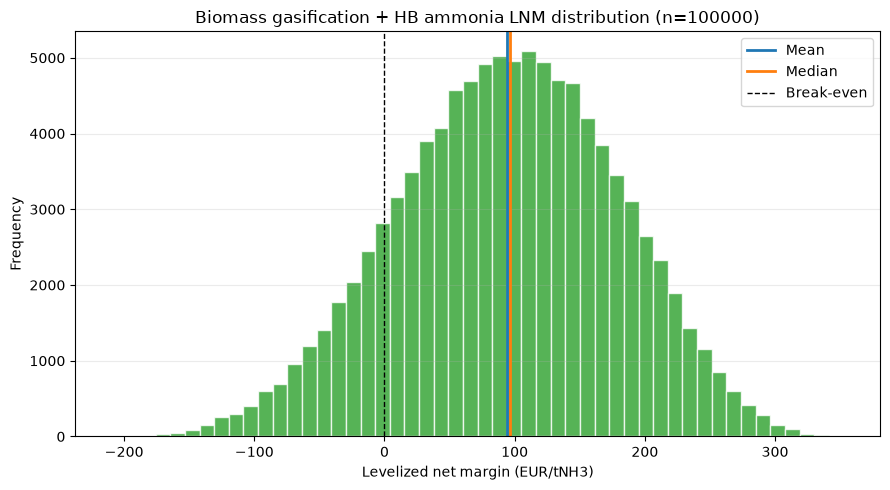

In [5]:
plot_financial_metric_distribution(
    levelized_net_margin_eur_per_tnh3,
    title=f"Biomass gasification + HB ammonia LNM distribution (n={SAMPLE_SIZE})",
    x_axis_label="Levelized net margin (EUR/tNH3)",
    color="tab:green",
    show_break_even=True,
)
plt.show()

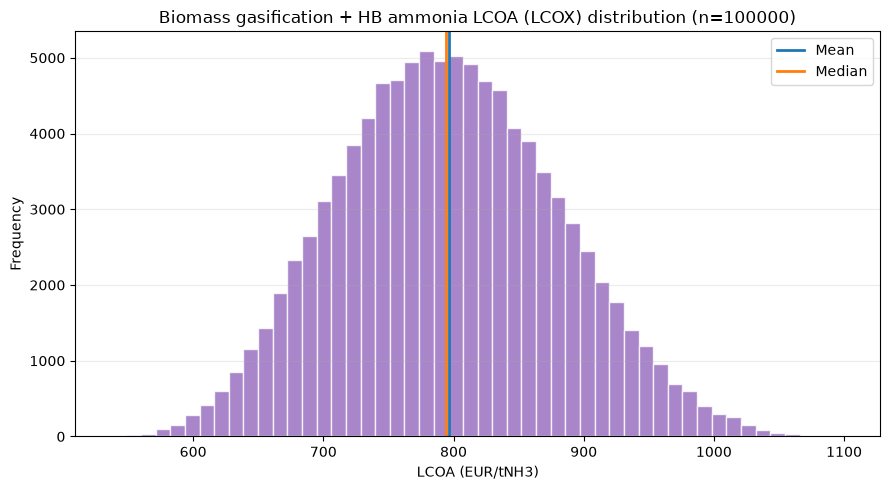

In [6]:
plot_financial_metric_distribution(
    lcoa_eur_per_tnh3,
    title=f"Biomass gasification + HB ammonia LCOA (LCOX) distribution (n={SAMPLE_SIZE})",
    x_axis_label="LCOA (EUR/tNH3)",
    color="tab:purple",
)
plt.show()

In [7]:
annual_columns = [
    "annual_revenue_eur",
    "annual_fixed_opex_eur",
    "annual_variable_opex_eur",
    "annual_natural_gas_cost_eur",
    "annual_coal_cost_eur",
    "annual_biomass_cost_eur",
    "annual_fuel_cost_eur",
    "annual_electricity_cost_eur",
    "annual_transport_and_storage_cost_eur",
    "annual_emissions_cost_eur",
    "annual_net_cash_flow_eur",
]
(results[annual_columns] / 1_000_000).mean().rename("Mean annual value, million EUR")

annual_revenue_eur                      890.000
annual_fixed_opex_eur                    35.608
annual_variable_opex_eur                 17.198
annual_natural_gas_cost_eur               0.000
annual_coal_cost_eur                      0.000
annual_biomass_cost_eur                 300.963
annual_fuel_cost_eur                    300.963
annual_electricity_cost_eur              45.476
annual_transport_and_storage_cost_eur     0.000
annual_emissions_cost_eur                 0.000
annual_net_cash_flow_eur                490.755
Name: Mean annual value, million EUR, dtype: float64